# Giảm chiều MNIST – Notebook chung (PCA / Chi-Square)

Một biến quyết định phương pháp; mọi phân nhánh nằm trong module `lib.reduction`. So sánh baseline vs sau giảm chiều: bộ nhớ, thời gian, độ chính xác.

## 1. Cấu hình và import

In [21]:
import sys
sys.path.insert(0, '.')

import warnings
warnings.filterwarnings('ignore')

from lib import (
    REDUCTION_METHODS,
    create_reducer,
    get_default_n_components_trials,
    MNISTDataLoader,
    MNISTClassifier,
    measure_array_memory_mb,
    run_and_measure_seconds,
    plot_comparison_reduction,
    print_comparison_table,
    plot_confusion_matrix,
    print_classification_report,
)
import matplotlib.pyplot as plt

In [22]:
METHOD = "pca"
N_COMPONENTS = 0.95
RANDOM_STATE = 42

print(f"Phương pháp: {METHOD}, n_components: {N_COMPONENTS}. \nCó thể đổi METHOD thành một trong {REDUCTION_METHODS}.")

Phương pháp: pca, n_components: 0.95. 
Có thể đổi METHOD thành một trong ('pca', 'chi2').


## 2. Tải dữ liệu

In [23]:
loader = MNISTDataLoader(normalize=True, flatten=True)
X_train, y_train, X_test, y_test = loader.load()

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Số chiều gốc: {X_train.shape[1]}")

X_train: (60000, 784), X_test: (10000, 784)
Số chiều gốc: 784


## 3. Baseline – Dữ liệu gốc

In [24]:
baseline_memory_mb = measure_array_memory_mb(X_train)
print(f"Bộ nhớ X_train (baseline): {baseline_memory_mb:.4f} MB")

Bộ nhớ X_train (baseline): 358.8867 MB


In [25]:
clf_baseline = MNISTClassifier(model_type="logistic", random_state=RANDOM_STATE)

_, time_fit_baseline = run_and_measure_seconds(lambda: clf_baseline.fit(X_train, y_train))
_, time_predict_baseline = run_and_measure_seconds(lambda: clf_baseline.predict(X_test))

acc_baseline = clf_baseline.score(X_test, y_test)

baseline_metrics = {
    "memory_mb": baseline_memory_mb,
    "time_fit_s": time_fit_baseline,
    "time_predict_s": time_predict_baseline,
    "accuracy": acc_baseline,
}
print(f"Baseline - Fit: {time_fit_baseline:.4f} s, Predict: {time_predict_baseline:.4f} s, Accuracy: {acc_baseline:.4f}")

Baseline - Fit: 19.6934 s, Predict: 0.0256 s, Accuracy: 0.9257


## 4. Giảm chiều

In [26]:
reducer = create_reducer(METHOD, n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_train_reduced = reducer.fit_transform(X_train, y_train, X_val=X_test, y_val=y_test)
X_test_reduced = reducer.transform(X_test)

print(f"Số chiều sau giảm: {reducer.n_components_}")
print(f"Tổng phương sai (PCA): {reducer.total_explained_variance_ratio()}")
print(f"Độ chính xác đạt (Chi-Square): {reducer.min_accuracy_reached()}")

Số chiều sau giảm: 154
Tổng phương sai (PCA): 0.9501960192613166
Độ chính xác đạt (Chi-Square): None


In [27]:
reduced_memory_mb = measure_array_memory_mb(X_train_reduced)
print(f"Bộ nhớ X_train (sau giảm chiều): {reduced_memory_mb:.4f} MB")

Bộ nhớ X_train (sau giảm chiều): 70.4956 MB


## 5. Đánh giá sau giảm chiều

In [28]:
clf_reduced = MNISTClassifier(model_type="logistic", random_state=RANDOM_STATE)

_, time_fit_reduced = run_and_measure_seconds(lambda: clf_reduced.fit(X_train_reduced, y_train))
_, time_predict_reduced = run_and_measure_seconds(lambda: clf_reduced.predict(X_test_reduced))

acc_reduced = clf_reduced.score(X_test_reduced, y_test)

reduced_metrics = {
    "memory_mb": reduced_memory_mb,
    "time_fit_s": time_fit_reduced,
    "time_predict_s": time_predict_reduced,
    "accuracy": acc_reduced,
}
print(f"Sau giảm chiều - Fit: {time_fit_reduced:.4f} s, Predict: {time_predict_reduced:.4f} s, Accuracy: {acc_reduced:.4f}")

Sau giảm chiều - Fit: 3.5998 s, Predict: 0.0052 s, Accuracy: 0.9229


## 6. So sánh và trực quan

In [29]:
print_comparison_table(baseline_metrics, reduced_metrics, reduced_name=f"Sau giảm chiều ({reducer.method_label})")

BẢNG SO SÁNH: BASELINE vs SAU GIẢM CHIỀU
Chỉ số                        Baseline Sau giảm chiều (PCA)   Chênh lệch
------------------------------------------------------------
Bộ nhớ (MB)                   358.8867      70.4956      +80.36%
Thời gian fit (s)              19.6934       3.5998
Thời gian predict (s)           0.0256       0.0052
Độ chính xác (%)                 92.57        92.29       +0.30% (hao hụt)


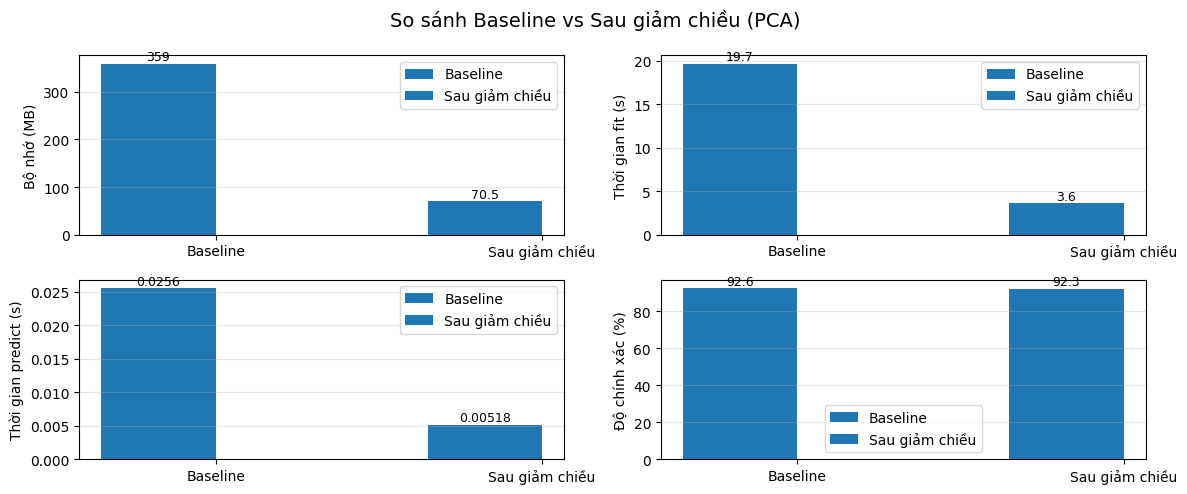

In [30]:
fig = plot_comparison_reduction(
    baseline_metrics,
    reduced_metrics,
    title=f"So sánh Baseline vs Sau giảm chiều ({reducer.method_label})",
)
plt.show()

## 7. Báo cáo phân lớp và Confusion Matrix

In [31]:
y_pred_reduced = clf_reduced.predict(X_test_reduced)
class_names = loader.get_class_names()

print(f"Báo cáo phân lớp – Sau giảm chiều ({reducer.method_label}):")
print_classification_report(y_test, y_pred_reduced, class_names=class_names)

Báo cáo phân lớp – Sau giảm chiều (PCA):
              precision    recall  f1-score   support

           0     0.9512    0.9745    0.9627       980
           1     0.9652    0.9780    0.9716      1135
           2     0.9217    0.9012    0.9113      1032
           3     0.9006    0.9059    0.9033      1010
           4     0.9281    0.9328    0.9304       982
           5     0.8977    0.8655    0.8813       892
           6     0.9391    0.9499    0.9445       958
           7     0.9329    0.9202    0.9265      1028
           8     0.8815    0.8860    0.8838       974
           9     0.9012    0.9039    0.9025      1009

    accuracy                         0.9229     10000
   macro avg     0.9219    0.9218    0.9218     10000
weighted avg     0.9227    0.9229    0.9227     10000



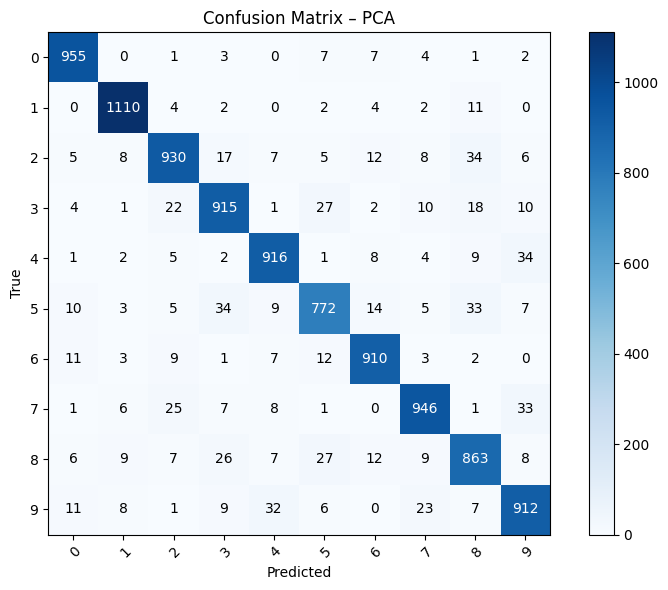

In [32]:
fig = plot_confusion_matrix(y_test, y_pred_reduced, class_names=class_names, title=f"Confusion Matrix – {reducer.method_label}")
plt.show()

## 8. Thử nhiều mức n_components

In [34]:
results = []
for nc in get_default_n_components_trials(METHOD):
    r = create_reducer(METHOD, n_components=nc, random_state=RANDOM_STATE)
    X_tr = r.fit_transform(X_train, y_train, X_val=X_test, y_val=y_test)
    X_te = r.transform(X_test)
    mem = measure_array_memory_mb(X_tr)
    clf = MNISTClassifier(model_type="logistic", random_state=RANDOM_STATE)
    clf.fit(X_tr, y_train)
    acc = clf.score(X_te, y_test)
    results.append({"n_components": nc, "dims": r.n_components_, "memory_mb": mem, "accuracy": acc})

print(f"METHOD={METHOD}")
print(f"{'n_components':>12} | {'Số chiều':>8} | {'Bộ nhớ (MB)':>11} | {'Accuracy':>8}")
for row in results:
    print(f"{row['n_components']:>12.4f} | {row['dims']:>8.0f} | {row['memory_mb']:>11.4f} | {row['accuracy']:>8.4f}")

METHOD=pca
n_components | Số chiều | Bộ nhớ (MB) | Accuracy
      0.9900 |      331 |    151.5198 |   0.9252
      0.9500 |      154 |     70.4956 |   0.9229
      0.9000 |       87 |     39.8254 |   0.9194
      0.8000 |       44 |     20.1416 |   0.9104
